## 1. Setup

### 1.0 Google Drive Sync
Pode ignorar essa seção se não estiver usando Google Colab

In [32]:
# Adicionar o conteúdo do drive no caminho do sistema

# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

In [33]:
# modificar para o diretorio que contem a pasta do repositorio ao rodar esse notebook
# fazemos isso para ele conseguir ler a pasta /datasets que precisa estar dentro do diretório que contem esse notebook
%cd /content/drive/MyDrive/projetos-if702/projeto-churn/

!dir

[WinError 3] The system cannot find the path specified: '/content/drive/MyDrive/projetos-if702/projeto-churn/'
c:\Users\User\Desktop\Redes neurais\projetos-if702\projeto-churn
 Volume in drive C has no label.
 Volume Serial Number is 92E5-FB3A

 Directory of c:\Users\User\Desktop\Redes neurais\projetos-if702\projeto-churn

06/07/2026  07:44 PM    <DIR>          .
06/07/2026  07:44 PM    <DIR>          ..
06/06/2026  02:37 PM             4,230 0_preprocessamento.ipynb
06/07/2026  08:55 PM            28,844 1_MLP.ipynb
06/04/2026  04:14 PM           395,387 2_XGBoost.ipynb
06/04/2026  04:14 PM             9,732 churn_preprocessing.py
06/05/2026  07:57 PM    <DIR>          datasets
06/07/2026  07:42 PM           309,321 KAN.ipynb
06/07/2026  07:44 PM            27,977 ml_utils.py
06/05/2026  09:53 PM    <DIR>          model
06/07/2026  07:45 PM    <DIR>          models
06/07/2026  07:44 PM    <DIR>          results
06/07/2026  07:44 PM    <DIR>          searches
06/04/2026  02:42 PM      

In [34]:
import sys

# Colocar o caminho exato da pasta onde está a pasta referente ao repositório do projeto
# O caminho base é sempre '/content/drive/MyDrive/' se criar um atalho no "Meu Drive" para a pasta sincronizada
caminho_projeto = '/content/drive/MyDrive/projetos-if702/projeto-churn'

# Adiciona a pasta no path do Python, caso ainda não esteja lá
if caminho_projeto not in sys.path:
    sys.path.append(caminho_projeto)

In [35]:

# Fazer recarregamento dos modulos locais.
# Assim não precisa reiniciar o kernel do colab toda vez que modificar alguma coisa nos arquivos .py

import importlib
sys.modules['imp'] = importlib

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 1.1 Importar Libs

In [36]:
import importlib
import ml_utils
import churn_preprocessing

importlib.invalidate_caches()
importlib.reload(ml_utils)
importlib.reload(churn_preprocessing)

<module 'churn_preprocessing' from 'c:\\Users\\User\\Desktop\\Redes neurais\\projetos-if702\\projeto-churn\\churn_preprocessing.py'>

In [37]:
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import optuna.visualization as optuna_vis
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import os
import torch
import json
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, confusion_matrix,)
from sklearn.model_selection import train_test_split
from scikitplot.metrics import plot_ks_statistic
from joblib import dump, load
import warnings
warnings.filterwarnings('ignore')

# Importar funções dos módulos customizados
from ml_utils import (
    train_model, evaluate_model, ks_test,
    build_hyperparameter_space, print_hyperparameter_space,
    run_optuna_search, get_loss_fn,
    DEFAULT_SCORING_METRIC, AVAILABLE_METRICS_SEARCH, AVAILABLE_LOSSES,
    RANDOM_STATE_MODEL, RANDOM_STATE_SAMPLE,
 )

from churn_preprocessing import load_split_datasets, get_X_y_from_split, OUTPUT_PREFIX, TARGET_COL

# Configurações de plotagem
plt.rcParams['figure.figsize'] = [12, 8]
sns.set_style("whitegrid")

print("Bibliotecas importadas com sucesso!")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")

## CPU ou GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device.type.upper())

Bibliotecas importadas com sucesso!
Pandas: 2.3.1
NumPy: 2.3.2
Scikit-learn: 1.7.2
Device: CUDA


### 1.2 Configuração do Modelo

In [38]:
# Configuração do modelo e hiperparâmetros
MODEL_NAME = "MLP"
MODEL_CLASS = MLPClassifier


# Configuração da busca de hiperparâmetros

module_name = getattr(MODEL_CLASS, "__module__", "")
print(f"Modelo configurado: {MODEL_NAME}")
print(module_name)

print("Hiperparâmetros disponíveis na classe do modelo:")
for param in MODEL_CLASS().get_params().keys():
    print(f"  - {param}")

Modelo configurado: MLP
sklearn.neural_network._multilayer_perceptron
Hiperparâmetros disponíveis na classe do modelo:
  - activation
  - alpha
  - batch_size
  - beta_1
  - beta_2
  - early_stopping
  - epsilon
  - hidden_layer_sizes
  - learning_rate
  - learning_rate_init
  - max_fun
  - max_iter
  - momentum
  - n_iter_no_change
  - nesterovs_momentum
  - power_t
  - random_state
  - shuffle
  - solver
  - tol
  - validation_fraction
  - verbose
  - warm_start


## 2. Carregamento dos Dados

In [39]:
# Carregamento e preparação inicial dos dados
print("=== CARREGAMENTO DOS DATASETS ===")

# Carregar e preparar datasets usando função do módulo
train_data, val_data, test_data = load_split_datasets(prefix=OUTPUT_PREFIX)
X_train, y_train, X_val, y_val, X_test, y_test = get_X_y_from_split(train_data, val_data, test_data, TARGET_COL)

# Manter nomes usados no restante do notebook
X_train_scaled = X_train
X_test_scaled = X_test

print(f"Dataset de treino: {train_data.shape}")
print(f"Dataset de validação: {val_data.shape}")
print(f"Dataset de teste: {test_data.shape}")
print(f"Features: {X_train_scaled.shape[1]}")

print("\nDistribuição das classes:")
print("Treino:", pd.Series(y_train).value_counts().to_dict())
print("Val:", pd.Series(y_val).value_counts().to_dict())
print("Teste:", pd.Series(y_test).value_counts().to_dict())


=== CARREGAMENTO DOS DATASETS ===
Dataset de treino: (5174, 20)
Dataset de validação: (2586, 20)
Dataset de teste: (1762, 20)
Features: 19

Distribuição das classes:
Treino: {0: 2587, 1: 2587}
Val: {0: 1293, 1: 1293}
Teste: {0: 1294, 1: 468}


In [40]:
print("\nPrimeiras linhas do dataset de treino:")
train_data.head()


Primeiras linhas do dataset de treino:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,PaperlessBilling_Yes,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaymentMethod,Churn
0,0.0,-0.181818,0.660499,0.051516,0.0,0.0,1.0,1.0,1.0,2.0,1.0,0.0,2.0,2.0,0.0,2.0,2.0,1.0,1.0,0
1,0.0,0.886364,-0.552846,0.591772,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2.0,2.0,2.0,0.0,0.0,2.0,1.0,2.0,0
2,0.0,0.681818,-0.318475,0.662118,1.0,1.0,1.0,1.0,0.0,0.0,0.0,2.0,2.0,0.0,2.0,0.0,0.0,2.0,1.0,0
3,0.0,-0.363636,0.239978,-0.249371,1.0,1.0,0.0,1.0,1.0,2.0,1.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,2.0,1
4,1.0,-0.068182,0.086347,0.092913,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,1


## 3. Busca de Hiperparâmetros

### 3.0 Sampling Para Busca
Pode escolher não usar também (ou usar frac=1.0)

In [41]:

SAMPLE_SIZE = 0.05  # % of training data for hyperparameter search
# Amostra estratificada do dataset de treino
_, X_sample, _, y_sample = train_test_split(
    X_train_scaled, y_train,
    test_size=SAMPLE_SIZE,
    stratify=y_train,
    random_state=RANDOM_STATE_SAMPLE
)

print(f"Dataset original de treino: {X_train_scaled.shape[0]:,} amostras")
print(f"Amostra para busca de hiperparâmetros: {X_sample.shape[0]:,} amostras")
print(f"Redução: {(1 - X_sample.shape[0]/X_train_scaled.shape[0])*100:.1f}%")

print("\nDistribuição das classes na amostra:")
print("Amostra:", pd.Series(y_sample).value_counts().to_dict())
print("Original:", pd.Series(y_train).value_counts().to_dict())


Dataset original de treino: 5,174 amostras
Amostra para busca de hiperparâmetros: 259 amostras
Redução: 95.0%

Distribuição das classes na amostra:
Amostra: {0: 130, 1: 129}
Original: {0: 2587, 1: 2587}


### 3.1 Configs da Busca Optuna

In [42]:
print("Métrica padrão de avaliação na busca de hiperparâmetros caso não especificada outra:", DEFAULT_SCORING_METRIC)
print("Métricas disponíveis para a busca de hiperparâmetros:\n", AVAILABLE_METRICS_SEARCH)
print("Funções de perda disponíveis para modelos PyTorch:\n", AVAILABLE_LOSSES)

Métrica padrão de avaliação na busca de hiperparâmetros caso não especificada outra: ks
Métricas disponíveis para a busca de hiperparâmetros:
 ['accuracy', 'precision', 'recall', 'f1', 'val_loss', 'auroc', 'ks']
Funções de perda disponíveis para modelos PyTorch:
 ['cross_entropy', 'bce_with_logits', 'mse']


In [43]:
# Optuna
n_trials = 100
scoring_metric = 'ks'
loss_fn = get_loss_fn('cross_entropy')

# modelos PyTorch somente
early_stopping_patience = 10
early_stopping_delta = 0.001
training_epochs_per_trial = 10

### 3.2 Definção do Espaço de Hiperparâmetros


In [44]:
# ======================================================================
# DEFINIÇÃO DO ESPAÇO DE HIPERPARÂMETROS
# ======================================================================

# Definir hiperparâmetros específicos para MLP

hidden_layer_sizes = [
    # 2 camadas
    (1024, 256),
    (1024, 512),
    (1536, 384),
    (2048, 256),
    # Variações de 3 camadas baseadas na melhor
    (1024, 384, 128),
    (1024, 384, 256),
    (1024, 512, 128),
    (1024, 512, 256),
    (1536, 384, 128),
    (1536, 512, 128),
    (2048, 384, 128),
    (2048, 512, 256),
    # 4 camadas
    (1024, 512, 256, 128),
    (1536, 512, 256, 128),
]

param_space = build_hyperparameter_space(
    MODEL_CLASS,
    overrides={
        "hidden_layer_sizes": {"type": "categorical", "values": hidden_layer_sizes},
        "alpha": {"type": "float", "values": [1e-5, 1e-1, None, True]},
        "learning_rate_init": {"type": "float", "values": [1e-4, 1e-1, None, True]},
        "max_iter": {"type": "int", "values": [200, 500]},
        "learning_rate": {"type": "categorical", "values": ["constant", "adaptive"]},
        "solver": {"type": "categorical", "values": ["lbfgs", "adam", "sgd"]},
        "batch_size": {"type": "categorical", "values": [32, 64, 128]},
    },
)

print_hyperparameter_space(param_space)

Hyperparameter space:
- hidden_layer_sizes: type=categorical, values=[(1024, 256), (1024, 512), (1536, 384), (2048, 256), (1024, 384, 128), (1024, 384, 256), (1024, 512, 128), (1024, 512, 256), (1536, 384, 128), (1536, 512, 128), (2048, 384, 128), (2048, 512, 256), (1024, 512, 256, 128), (1536, 512, 256, 128)]
- alpha: type=float, args=[1e-05, 0.1], kwargs={'log': True}
- learning_rate_init: type=float, args=[0.0001, 0.1], kwargs={'log': True}
- max_iter: type=int, args=[200, 500], kwargs={}
- learning_rate: type=categorical, values=['constant', 'adaptive']
- solver: type=categorical, values=['lbfgs', 'adam', 'sgd']
- batch_size: type=categorical, values=[32, 64, 128]


### 3.3 Executar Busca de Hiperparâmetros

In [45]:

print(f"=== BUSCA DE HIPERPARÂMETROS - {MODEL_NAME} ===")
print(f"Iniciando busca de hiperparâmetros para {MODEL_NAME}...")
print(f"Trials: {n_trials}")
print(f"Usando amostra de {X_sample.shape[0]:,} exemplos\n")
print(f"Hiperparâmetros no espaço: {list(param_space.keys())}")

direction = "minimize" if scoring_metric in {"val_loss", "loss"} else "maximize"
study = run_optuna_search(
    model_class=MODEL_CLASS,
    space=param_space,
    X_train=X_sample,
    y_train=y_sample,
    X_val=X_val,
    y_val=y_val,
    n_trials=n_trials,
    direction=direction,
    scoring_metric=scoring_metric,
    device=device,
    epochs=training_epochs_per_trial,
    patience=early_stopping_patience,
    min_delta=early_stopping_delta,
    loss_fn=loss_fn,
 )

print(f"\n--- RESULTADOS {MODEL_NAME} ---")
print("Melhores hiperparâmetros encontrados:")
for param, value in study.best_params.items():
    print(f"  {param}: {value}")
print(f"\nMelhor score ({scoring_metric}): {study.best_value:.6f}")

[I 2026-06-07 20:55:43,857] A new study created in memory with name: no-name-8217ce89-a2d9-472e-b85b-48b828077835


=== BUSCA DE HIPERPARÂMETROS - MLP ===
Iniciando busca de hiperparâmetros para MLP...
Trials: 100
Usando amostra de 259 exemplos

Hiperparâmetros no espaço: ['hidden_layer_sizes', 'alpha', 'learning_rate_init', 'max_iter', 'learning_rate', 'solver', 'batch_size']


[I 2026-06-07 20:55:50,245] Trial 0 finished with value: 0.46481051817478736 and parameters: {'hidden_layer_sizes': (1024, 384, 128), 'alpha': 2.5226385263250236e-05, 'learning_rate_init': 0.0037699882610943494, 'max_iter': 406, 'learning_rate': 'adaptive', 'solver': 'sgd', 'batch_size': 128}. Best is trial 0 with value: 0.46481051817478736.
[I 2026-06-07 20:56:01,899] Trial 1 finished with value: 0.4609435421500387 and parameters: {'hidden_layer_sizes': (1024, 512), 'alpha': 0.0001448698372098741, 'learning_rate_init': 0.0011703853736226822, 'max_iter': 411, 'learning_rate': 'adaptive', 'solver': 'sgd', 'batch_size': 64}. Best is trial 0 with value: 0.46481051817478736.
[I 2026-06-07 20:56:03,093] Trial 2 finished with value: 0.477184841453983 and parameters: {'hidden_layer_sizes': (1024, 512), 'alpha': 0.008176246084405292, 'learning_rate_init': 0.01951430214627027, 'max_iter': 331, 'learning_rate': 'adaptive', 'solver': 'adam', 'batch_size': 128}. Best is trial 2 with value: 0.47718


--- RESULTADOS MLP ---
Melhores hiperparâmetros encontrados:
  hidden_layer_sizes: (1024, 512, 128)
  alpha: 5.5646880460811174e-05
  learning_rate_init: 0.00047467372028218605
  max_iter: 289
  learning_rate: constant
  solver: sgd
  batch_size: 64

Melhor score (ks): 0.501933


### 3.4 Visualizar Histórico da Busca

In [46]:
# Registro de Desempenho - plotar evolução da busca
optuna_vis.plot_param_importances(study)

In [47]:
optuna_vis.plot_optimization_history(study, target_name=scoring_metric)


In [48]:
optuna_vis.plot_parallel_coordinate(study, params=list(param_space.keys()), target_name=scoring_metric)

In [49]:

print(f"=== MELHORES CONFIGURAÇÕES ENCONTRADAS - {MODEL_NAME} ===")

trials_df = study.trials_dataframe()
if "state" in trials_df.columns:
    trials_df = trials_df[trials_df["state"] == "COMPLETE"]
sorted_df = trials_df.sort_values("value", ascending=(direction == "minimize"))

print(f"\nTop configurações (de {len(sorted_df)} trials completos):")
print(sorted_df.head(10).to_string(index=False))

if not sorted_df.empty:
    print(f"\nEstatísticas dos scores encontrados:")
    print(f"  Média: {sorted_df['value'].mean():.4f}")
    print(f"  Mediana: {sorted_df['value'].median():.4f}")
    print(f"  Desvio padrão: {sorted_df['value'].std():.4f}")
    print(f"  Min: {sorted_df['value'].min():.4f}")
    print(f"  Max: {sorted_df['value'].max():.4f}")

=== MELHORES CONFIGURAÇÕES ENCONTRADAS - MLP ===

Top configurações (de 100 trials completos):
 number    value             datetime_start          datetime_complete               duration  params_alpha  params_batch_size params_hidden_layer_sizes params_learning_rate  params_learning_rate_init  params_max_iter params_solver    state
     64 0.501933 2026-06-07 21:04:32.362918 2026-06-07 21:04:41.635754 0 days 00:00:09.272836      0.000056                 64          (1024, 512, 128)             constant                   0.000475              289           sgd COMPLETE
     62 0.499613 2026-06-07 21:04:14.731381 2026-06-07 21:04:23.597097 0 days 00:00:08.865716      0.000042                 64          (1024, 512, 128)             constant                   0.000583              286           sgd COMPLETE
     83 0.498067 2026-06-07 21:08:01.292206 2026-06-07 21:08:08.168141 0 days 00:00:06.875935      0.000034                 64          (1536, 384, 128)             constant         

## 4. Salvar Resultados de Busca

In [50]:
SEARCH_RESULTS_FOLDER = "searches"
os.makedirs(SEARCH_RESULTS_FOLDER, exist_ok=True)

trials_path = os.path.join(SEARCH_RESULTS_FOLDER, f"{MODEL_NAME.lower()}_optuna_trials.csv")
best_params_path = os.path.join(SEARCH_RESULTS_FOLDER, f"{MODEL_NAME.lower()}_optuna_best.json")

trials_df.to_csv(trials_path, index=False)
with open(best_params_path, "w") as f:
    json.dump(study.best_params, f, indent=2, default=str)

print("Resultados da busca salvos:")
print(trials_path)
print(best_params_path)

Resultados da busca salvos:
searches\mlp_optuna_trials.csv
searches\mlp_optuna_best.json


In [51]:
# Rodar essa célula mesmo que não carregue os resultados da busca
# para evitar erro na seção 6
loaded_best_params = None
loaded_trials_df = None

## 5. Carregar Resultado de Busca (Opcional)

In [52]:
if os.path.exists(trials_path):
    loaded_trials_df = pd.read_csv(trials_path)
if os.path.exists(best_params_path):
    with open(best_params_path, "r") as f:
        loaded_best_params = json.load(f)

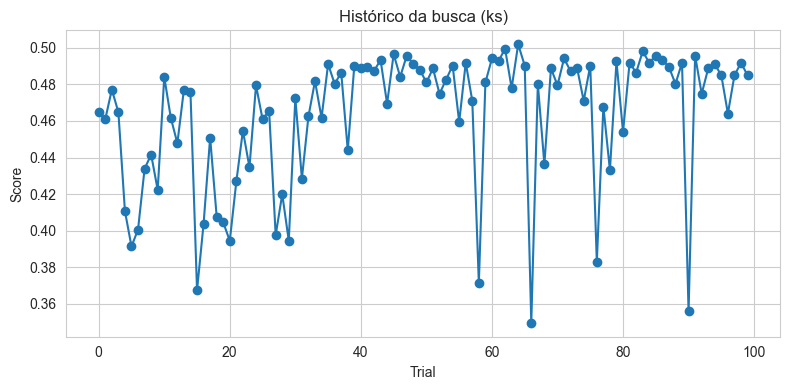

In [53]:
# Plotar a história da busca a partir dos resultados carregados
if loaded_trials_df is not None and "value" in loaded_trials_df.columns:
    plot_df = loaded_trials_df.sort_values("number") if "number" in loaded_trials_df.columns else loaded_trials_df
    plt.figure(figsize=(8, 4))
    plt.plot(plot_df["value"].values, marker="o")
    plt.title(f"Histórico da busca ({scoring_metric})")
    plt.xlabel("Trial")
    plt.ylabel("Score")
    plt.tight_layout()
    plt.show()

## 6. Definir Melhores Params e Score de Busca

In [54]:
# Definir Melhores Parâmetros para Uso Posterior
if loaded_best_params is not None:
    best_params = loaded_best_params
    if loaded_trials_df is not None and "value" in loaded_trials_df.columns:
        best_score = (
            loaded_trials_df["value"].min()
            if direction == "minimize"
            else loaded_trials_df["value"].max()
        )
    else:
        best_score = study.best_value
    print(f"✅ Usando parâmetros carregados: {best_params}")
    print(f"✅ Melhor score carregado: {best_score:.6f}")
else:
    best_params = study.best_params
    best_score = study.best_value
    print(f"✅ Usando parâmetros da busca atual: {best_params}")
    print(f"✅ Melhor score da busca atual: {best_score:.6f}")

if isinstance(best_params.get("hidden_layer_sizes"), str):
    best_params["hidden_layer_sizes"] = eval(best_params["hidden_layer_sizes"])

✅ Usando parâmetros carregados: {'hidden_layer_sizes': [1024, 512, 128], 'alpha': 5.5646880460811174e-05, 'learning_rate_init': 0.00047467372028218605, 'max_iter': 289, 'learning_rate': 'constant', 'solver': 'sgd', 'batch_size': 64}
✅ Melhor score carregado: 0.501933


## 7. Treinar Modelo Final e Salvar

In [55]:
best_model = MODEL_CLASS(**best_params, random_state=RANDOM_STATE_MODEL)
best_model.fit(X_train_scaled, y_train)

,hidden_layer_sizes,"[1024, 512, ...]"
,activation,'relu'
,solver,'sgd'
,alpha,5.5646880460811174e-05
,batch_size,64
,learning_rate,'constant'
,learning_rate_init,0.00047467372028218605
,power_t,0.5
,max_iter,289
,shuffle,True
,random_state,42


In [56]:
# Salvar o modelo treinado com os melhores hiperparâmetros 
MODELS_FOLDER = "models"
os.makedirs(MODELS_FOLDER, exist_ok=True)

model_path = os.path.join(MODELS_FOLDER, f'{MODEL_NAME.lower().replace(" ", "_")}_model.joblib')
dump(best_model, model_path)

print(f" Model saved to: {model_path}")

 Model saved to: models\mlp_model.joblib


## 8. Avaliação Final e Salvamento dos Resultados

In [57]:
# Carregar modelo (Opcional)
loaded_model = load(model_path)

In [58]:
print(f"=== AVALIAÇÃO E SALVAMENTO DOS RESULTADOS - {MODEL_NAME} ===")

# Criar pastas se não existirem
RESULTS_FOLDER = "results"
os.makedirs(RESULTS_FOLDER, exist_ok=True)

# Avaliação completa do modelo
print("\nAvaliando:", MODEL_NAME)

# Usar datasets completos para avaliação final
X_train_eval = X_train_scaled
y_train_eval = y_train
X_test_eval = X_test_scaled
y_test_eval = y_test

# Avaliar modelo usando função do módulo
train_metrics, y_train_pred, y_train_scores = evaluate_model(
    best_model, X_train_eval, y_train_eval, device=device
 )
test_metrics, y_test_pred, y_test_scores = evaluate_model(
    best_model, X_test_eval, y_test_eval, device=device
 )

=== AVALIAÇÃO E SALVAMENTO DOS RESULTADOS - MLP ===

Avaliando: MLP


### 8.1 Classification Report

In [59]:
print(classification_report(y_test_eval, y_test_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.87      0.76      0.81      1294
           1       0.51      0.69      0.58       468

    accuracy                           0.74      1762
   macro avg       0.69      0.72      0.70      1762
weighted avg       0.77      0.74      0.75      1762



KS Statistic: 0.4668


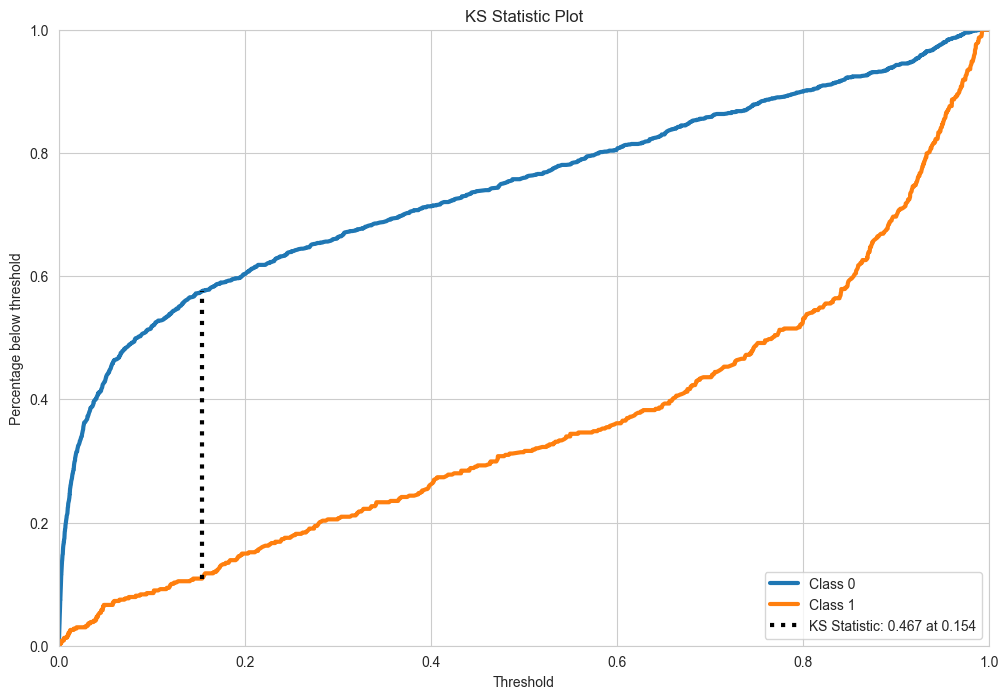

In [60]:
result = ks_test(y_test_eval, y_test_scores)
probas = result["probas"]
print(f"KS Statistic: {result['ks_stat']:.4f}")
ax = plot_ks_statistic(y_test_eval, probas)



### 8.2 Visualize Confusion Matrix

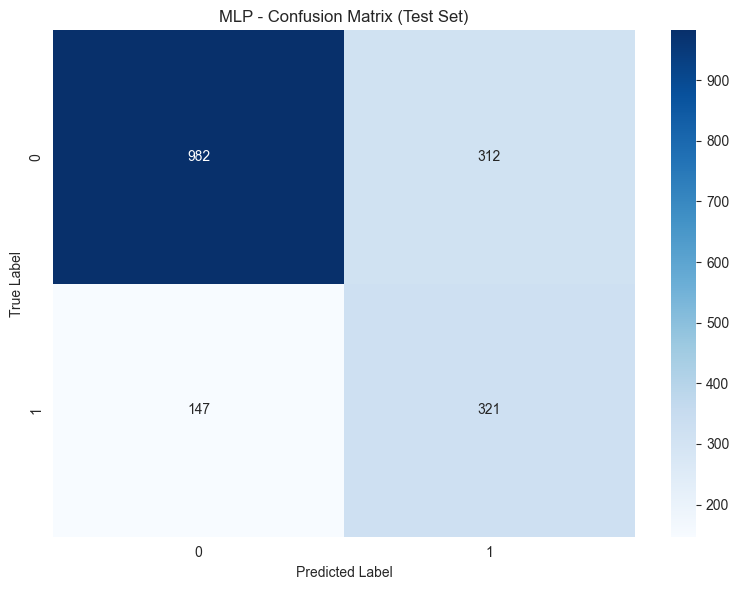

In [61]:
# Plot confusion matrix
cm = confusion_matrix(y_test_eval, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title(f'{MODEL_NAME} - Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

### 8.3 Save Final Results

In [62]:
# Salvar resultados finais
RESULTS_FOLDER = "results"
os.makedirs(RESULTS_FOLDER, exist_ok=True)

final_results = {
    "model_name": MODEL_NAME,
    "best_params": best_params,
    "best_score": best_score,
    "train_metrics": train_metrics,
    "test_metrics": test_metrics,
}

final_path = os.path.join(RESULTS_FOLDER, f"{MODEL_NAME.lower()}_final_results.json")
with open(final_path, "w") as f:
    json.dump(final_results, f, indent=2, default=str)

# Mostrar resumo final
print(f"\n--- RESUMO FINAL {MODEL_NAME} ---")
print(f"Score da busca: {best_score:.6f}")
print(f"KS Statistic Teste: {test_metrics['ks_stat']:.4f}")
print(f"AUC-ROC Teste: {test_metrics['auroc']:.4f}")
print(f"F1-Score Teste: {test_metrics['f1']:.4f}")
print(f"Acurácia Teste: {test_metrics['accuracy']:.4f}")
print(f"Precisão Teste: {test_metrics['precision']:.4f}")
print(f"Recall Teste: {test_metrics['recall']:.4f}")


print(f"Resultados salvos em: {RESULTS_FOLDER}/")
print(f"Arquivo final: {final_path}")


--- RESUMO FINAL MLP ---
Score da busca: 0.501933
KS Statistic Teste: 0.4668
AUC-ROC Teste: 0.8108
F1-Score Teste: 0.5831
Acurácia Teste: 0.7395
Precisão Teste: 0.5071
Recall Teste: 0.6859
Resultados salvos em: results/
Arquivo final: results\mlp_final_results.json
